# Example: solving the forward problem

In [1]:
from odil_wave import Grid
grid = Grid(interior_shape=(50, 50), interior_extent=((0.0, 1.0), (0.0, 1.0)), cfl_safety=0.9, pml_power=1)

In [2]:
print(grid.summary)

Grid interior 50x50 -> total 70x70 (PML p=10),
nt=219, dx=0.0204m, dy=0.0204m,
dt=0.0086 s, cfl@c_ref=0.899,
interior x in [0.00, 1.00]m,
y in [0.00, 1.00]m,
total x in [-0.20, 1.20]m,
total y in [-0.20, 1.20]m


The time discretisation is computed automatically from the spatial spec according to the CFL condition.

The `Grid` class also computes boundary damping profiles and bounds the grid with additional nodes to enforce them. Let's look at this more.

<Axes: title={'center': 'PML absorption $\\sigma_x + \\sigma_y$'}, xlabel='x [m]', ylabel='y [m]'>

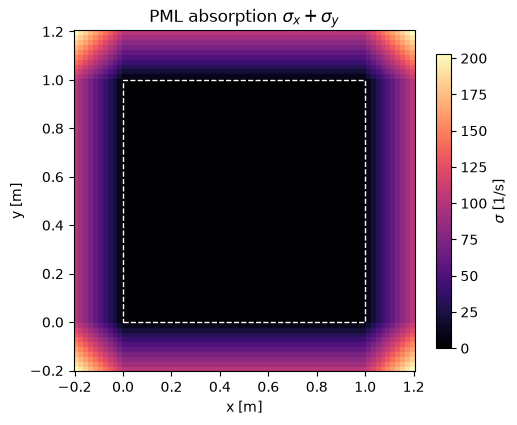

In [3]:
grid.plot_absorption_profile()

From a `Grid`, we can start to build the other components of the problem. First, let's build a velocity model.

<Axes: title={'center': 'c(x, y) [Shepp-Logan Phantom Model]'}, xlabel='x [m]', ylabel='y [m]'>

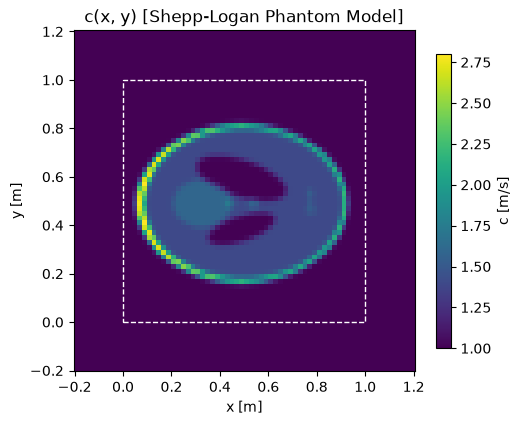

In [14]:
from odil_wave import SheppLoganModel

model = SheppLoganModel(grid=grid, contrast=2.0, interior_fill=0.95)
model.show()

Amplitude data can be represented by a `Wavefield` object:

In [15]:
from odil_wave import Wavefield
wavefield = Wavefield(grid=grid)

Amplitude data is initialised to zero by default.

To drive wave propagation, we need a source term. We can define sources using the `Sources` class. Sources can be placed in a ring, or using custom spatial position in (x, y) coordinates. Source injection is controlled by sink interpolation, which is a way to represent a point source exactly on a discrete grid. 

In [20]:
from odil_wave.geometry import Sources 
sources = Sources(grid, n_sources=1, mode="custom", source_locs=((0.95, 0.5),))

<Axes: title={'center': 'Sources on Shepp-Logan Phantom Model'}, xlabel='x [m]', ylabel='y [m]'>

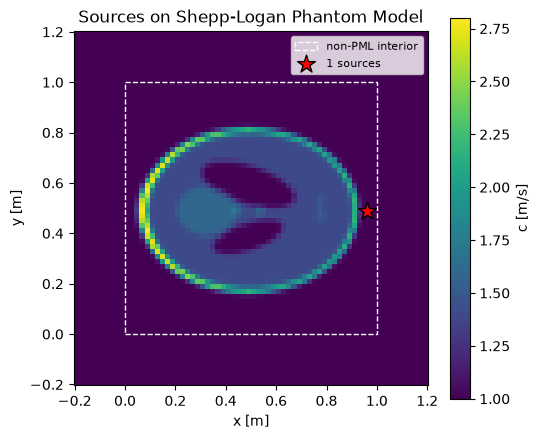

In [21]:
sources.show(model)

We can now move towards the physics of our problem. The discretisation scheme is controlled by operators of type `Operator` and there are a few options, but thankfully we can just specify the desired method order in time and space to a `WaveEquation` object and it will construct our operators along with objects that apply initial and boundary conditions. 

In [22]:
from odil_wave import WaveEquation
wave_eq = WaveEquation(wavefield, model, time_order=2, space_order=2)

To form a loss function, we can use a `ForwardLoss` object that should be configured by defining our `Problem`.

In [23]:
from odil_wave import Problem
problem = Problem(wave_eq=wave_eq, geometry=sources)

In [24]:
from odil_wave import ForwardLoss
loss = ForwardLoss(problem=problem)

Our `loss` keeps a `LossTape` that we can use to investigate the loss history after optimisation. First, let's define an optimiser. The optimiser type and various parameters can be configured by using a `ScipyOptimiser` object, but we will just use teh convenience class `LBFGSB`. 

In [14]:
from odil_wave import LBFGSB
optimiser = LBFGSB(loss)

First, let's look at what the intial loss and gradient looks like:

In [17]:
import numpy as np

loss_val, grad = loss.evaluate(wavefield.U)
print("loss:", loss_val)
print("grad norm:", np.linalg.norm(grad))
print("grad max:", np.abs(grad).max())

loss: 27.29464729526763
grad norm: 7376.886717722498
grad max: 1360.2126401478827


Finally, we can run the optimisation.

In [24]:
wavefield, tape = optimiser.minimise(maxiter=1000, ftol=1e-6, gtol=1e-8)

In [25]:
tape.result

  message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 0.02967359011104547
        x: [ 8.899e-09  3.253e-08 ... -1.562e-09  1.114e-10]
      nit: 1000
      jac: [-1.690e-04 -5.345e-04 ...  1.549e-01  7.382e-02]
     nfev: 1030
     njev: 1030
 hess_inv: <367500x367500 LbfgsInvHessProduct with dtype=float64>

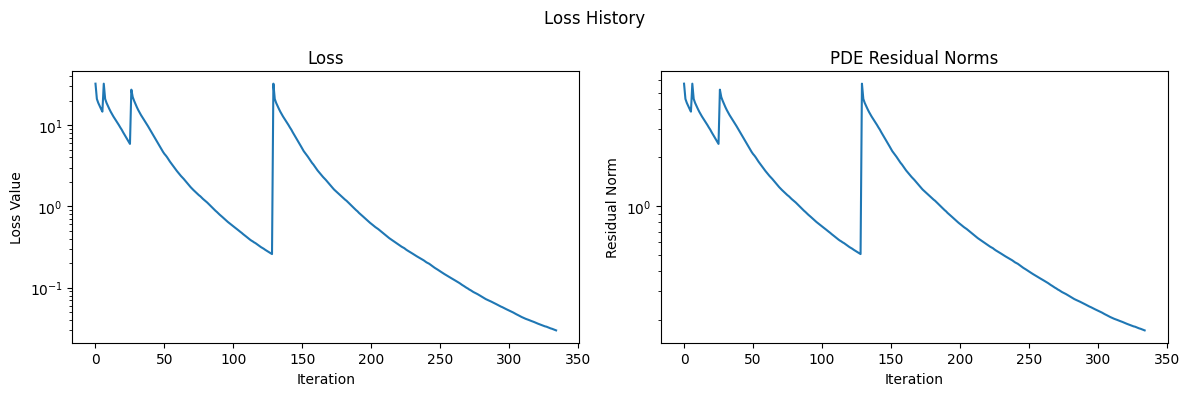

In [26]:
tape.show()

In [27]:
outfile = wavefield.animate()

While iterative methods can produce a decent result, we can also use a Gauss-Newton method:

In [25]:
from odil_wave.optimisation import GaussNewtonOptimiser
optimiser = GaussNewtonOptimiser(loss, outer_maxiter=100)

In [26]:
result, tape = optimiser.minimise(wavefield, method="cg", inner_maxiter=50) # inner solve JTJ du = -JT r using cg

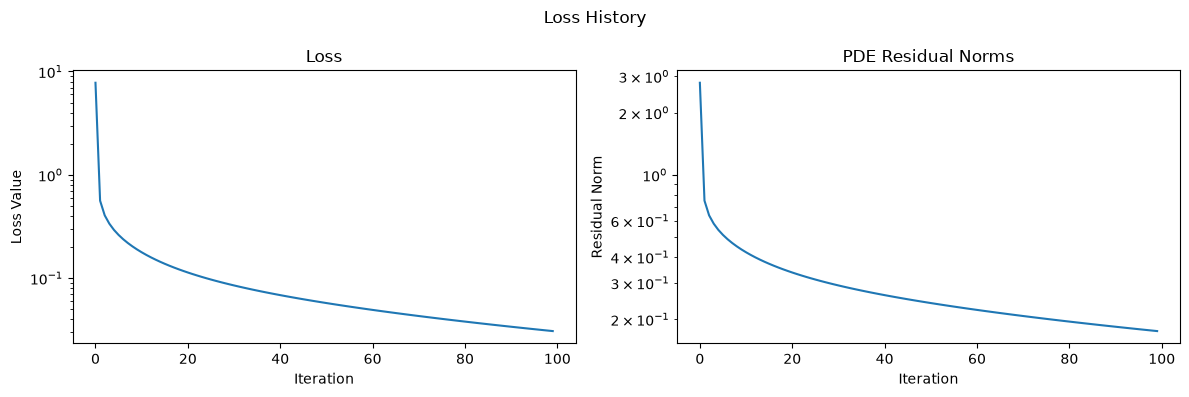

In [27]:
tape.show()

In [28]:
outfile = result.animate()